# 🚀 Day 6: Machine Learning Workflow & Train-Test Split

## 30 Days of Machine Learning Challenge

Today I am learning the basic Machine Learning workflow
and how to split a dataset into training and testing data.

### Objectives

- Understand the ML workflow
- Identify features and target
- Understand training and testing data
- Perform train-test split
- Understand test_size
- Understand random_state
- Prepare data for model training

## 🔄 Machine Learning Workflow

A typical Machine Learning workflow is:

1. Collect Data
2. Explore Data
3. Clean Data
4. Preprocess Data
5. Select Features
6. Separate Features and Target
7. Split Data
8. Train Model
9. Make Predictions
10. Evaluate Model
11. Improve Model

In [1]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
#Create Dataset
data = {
    "Study_Hours": [1, 2, 2.5, 3, 3.5, 4, 5, 5.5, 6, 7],
    "Marks": [35, 42, 48, 55, 60, 65, 72, 78, 85, 92]
}

df = pd.DataFrame(data)

df

,Study_Hours,Marks
0,1.0,35
1,2.0,42
2,2.5,48
3,3.0,55
4,3.5,60
5,4.0,65
6,5.0,72
7,5.5,78
8,6.0,85
9,7.0,92


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()
print("\nStatistical Summary:")
df.describe()

Shape: (10, 2)

Columns:
Index(['Study_Hours', 'Marks'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study_Hours  10 non-null     float64
 1   Marks        10 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 292.0 bytes

Statistical Summary:


,Study_Hours,Marks
count,10.000000,10.000000
mean,3.950000,63.200000
std,1.906859,18.730842
min,1.000000,35.000000
25%,2.625000,49.750000
50%,3.750000,62.500000
75%,5.375000,76.500000
max,7.000000,92.000000


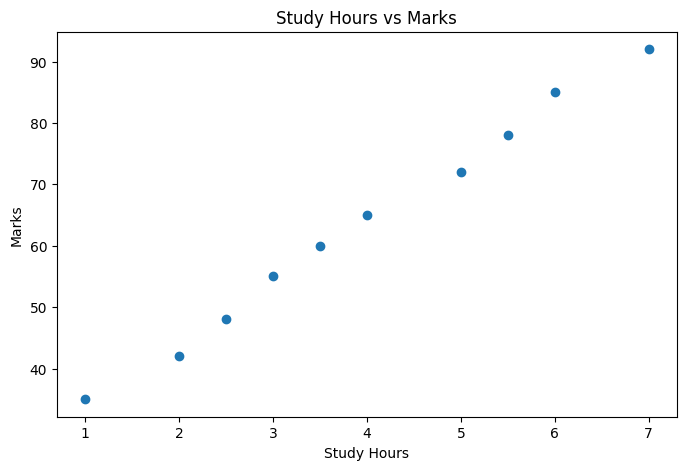

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study_Hours"],
    df["Marks"]
)

plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")

plt.show()

Observation

As study hours increase, marks generally increase in this sample dataset.

This suggests that Study_Hours could be a useful feature for predicting Marks.

## 🎯 Features and Target

### Feature

The feature is the input variable used by the model.

Here:

`Study_Hours` → Feature

### Target

The target is the value we want to predict.

Here:

`Marks` → Target

In [5]:
X = df[["Study_Hours"]]

y = df["Marks"]

print("Features (X):")
print(X)

print("\nTarget (y):")
print(y)

Features (X):
   Study_Hours
0          1.0
1          2.0
2          2.5
3          3.0
4          3.5
5          4.0
6          5.0
7          5.5
8          6.0
9          7.0

Target (y):
0    35
1    42
2    48
3    55
4    60
5    65
6    72
7    78
8    85
9    92
Name: Marks, dtype: int64


## ✂️ Why Train-Test Split?

We should not train and evaluate a model using exactly the same data.

If we do this, the model may appear to perform very well because it has already seen the data.

Instead:

Training Data → Used to learn patterns

Testing Data → Used to evaluate performance on unseen data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Check the Split
print("X_train:")
print(X_train)
print("\nX_test:")
print(X_test)
print("\ny_train:")
print(y_train)
print("\ny_test:")
print(y_test)

X_train:
   Study_Hours
5          4.0
0          1.0
7          5.5
2          2.5
9          7.0
4          3.5
3          3.0
6          5.0

X_test:
   Study_Hours
8          6.0
1          2.0

y_train:
5    65
0    35
7    78
2    48
9    92
4    60
3    55
6    72
Name: Marks, dtype: int64

y_test:
8    85
1    42
Name: Marks, dtype: int64


In [8]:
#Check Dataset Sizes
print("Total Records:", len(df))
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

# With test_size=0.2, approximately 80% goes to training and 20% to testing.

Total Records: 10
Training Records: 8
Testing Records: 2


## 📌 test_size

`test_size` determines how much data is reserved for testing.

Examples:

test_size = 0.2 → 20% testing, 80% training

test_size = 0.3 → 30% testing, 70% training

test_size = 0.1 → 10% testing, 90% training

In [9]:
# Understanding random_state
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 🎲 random_state

`random_state` controls the randomness used while splitting the data.

Using the same value produces the same split every time.

This makes our experiments reproducible.

## 🎲 random_state

`random_state` controls the randomness used while splitting the data.

Using the same value produces the same split every time.

This makes our experiments reproducible.

## ⚠️ Data Leakage

Data leakage happens when information that should not be available
during training is accidentally used by the model.

This can produce unrealistically good model performance.

### Example

If we calculate preprocessing statistics using the entire dataset
before splitting it, information from the test set can influence
the training process.

### Best Practice

Split the data first when appropriate, and fit preprocessing
steps only on the training data.

In [10]:
# 1. Create features and target
X = df[["Study_Hours"]]
y = df["Marks"]

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 3. Display sizes
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (8, 1)
Testing Features: (2, 1)
Training Target: (8,)
Testing Target: (2,)


# 🎯 Key Takeaways

✅ Machine Learning follows a structured workflow

✅ Features are input variables

✅ Target is the value we want to predict

✅ Training data is used to learn patterns

✅ Testing data evaluates the model on unseen data

✅ `test_size` controls the testing proportion

✅ `random_state` makes the split reproducible

✅ Data leakage can lead to misleadingly high performance

### Next Step

➡️ Day 7 – Linear Regression 🚀